In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")

✅ Setup complete!


In [20]:
# Load both raw and cleaned data
print("Loading datasets...")
train_raw = pd.read_csv('../data/raw/train_data.csv')
train_clean = pd.read_csv('../data/processed/train_cleaned.csv')

print(f"Raw shape: {train_raw.shape}")
print(f"Clean shape: {train_clean.shape}")
print(f"Rows removed: {len(train_raw) - len(train_clean):,}")
print("✅ Data loaded!")

Loading datasets...
Raw shape: (1722990, 23)
Clean shape: (1722990, 21)
Rows removed: 0
✅ Data loaded!


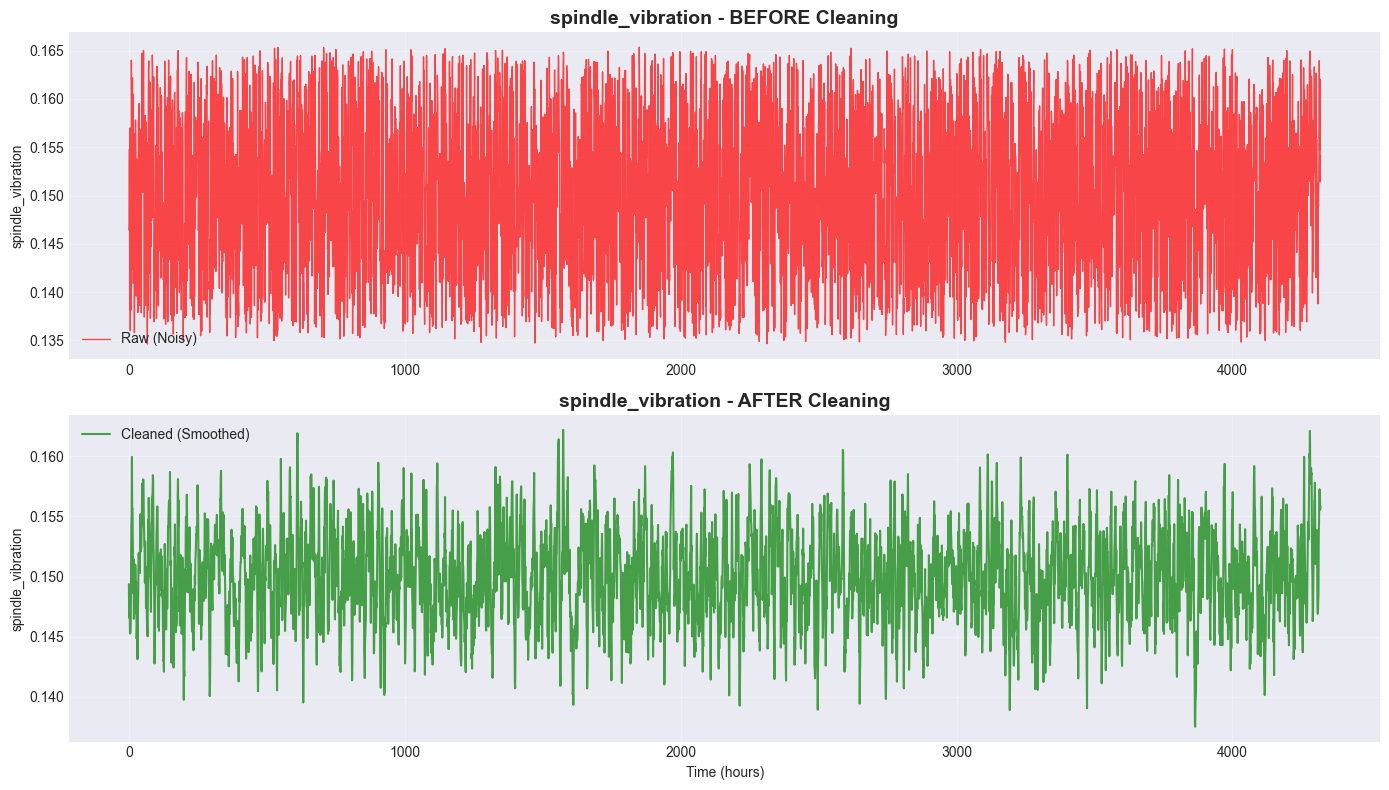

✅ Saved: before_after_cleaning.png


In [21]:
# Compare one sensor before and after
sensor = 'spindle_vibration'
machine_id = 1

# Get data for one machine
raw_data = train_raw[train_raw['machine_id'] == machine_id][sensor]
clean_data = train_clean[train_clean['machine_id'] == machine_id][sensor]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Before
ax1.plot(raw_data.values, alpha=0.7, linewidth=1, color='red', label='Raw (Noisy)')
ax1.set_title(f'{sensor} - BEFORE Cleaning', fontsize=14, fontweight='bold')
ax1.set_ylabel(sensor)
ax1.legend()
ax1.grid(True, alpha=0.3)

# After
ax2.plot(clean_data.values, alpha=0.7, linewidth=1.5, color='green', label='Cleaned (Smoothed)')
ax2.set_title(f'{sensor} - AFTER Cleaning', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel(sensor)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda/before_after_cleaning.png', dpi=300)
plt.show()

print("✅ Saved: before_after_cleaning.png")

In [22]:
# Get sensor columns
sensor_cols = [col for col in train_raw.columns if col in [
    'spindle_temp', 'spindle_vibration', 'motor_current', 'tool_vibration', 
    'tool_wear', 'hydraulic_pressure', 'acoustic_emission'
]]

print("="*70)
print("CLEANING IMPACT - STATISTICS COMPARISON")
print("="*70)

for sensor in sensor_cols:
    std_before = train_raw[sensor].std()
    std_after = train_clean[sensor].std()
    noise_reduction = ((std_before - std_after) / std_before * 100)
    
    print(f"\n{sensor}:")
    print(f"  Std Dev Before: {std_before:.4f}")
    print(f"  Std Dev After:  {std_after:.4f}")
    print(f"  Noise Reduced:  {noise_reduction:.2f}%")

print("\n✅ Data cleaning reduced noise while preserving patterns!")

CLEANING IMPACT - STATISTICS COMPARISON

spindle_temp:
  Std Dev Before: 2.6052
  Std Dev After:  1.1665
  Noise Reduced:  55.22%

spindle_vibration:
  Std Dev Before: 0.0089
  Std Dev After:  0.0039
  Noise Reduced:  56.40%

hydraulic_pressure:
  Std Dev Before: 8.6729
  Std Dev After:  3.8828
  Noise Reduced:  55.23%

motor_current:
  Std Dev Before: 0.6943
  Std Dev After:  0.3107
  Noise Reduced:  55.24%

tool_vibration:
  Std Dev Before: 0.0050
  Std Dev After:  0.0021
  Noise Reduced:  58.04%

tool_wear:
  Std Dev Before: 0.1461
  Std Dev After:  0.1448
  Noise Reduced:  0.88%

acoustic_emission:
  Std Dev Before: 2.3210
  Std Dev After:  1.0373
  Noise Reduced:  55.31%

✅ Data cleaning reduced noise while preserving patterns!


In [23]:
print("\n" + "="*70)
print("✅ DATA CLEANING COMPLETE!")
print("="*70)
print("\nCleaned Files Created:")
print("  ✅ data/processed/train_cleaned.csv")
print("  ✅ data/processed/test_cleaned.csv")
print("\nNext Step: Feature Engineering!")
print("="*70)


✅ DATA CLEANING COMPLETE!

Cleaned Files Created:
  ✅ data/processed/train_cleaned.csv
  ✅ data/processed/test_cleaned.csv

Next Step: Feature Engineering!
